In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("web_data_analysis.csv")

In [5]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.52666667,0.607594937,4.673333333,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737828,0.634615385,4.29588015,0.494382022,1147
3,Direct,2024041723,188,233,115,39.93991416,0.611702128,4.587982833,0.493562232,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.668449198,4.078125,0.48828125,1044


In [6]:
df.columns=df.iloc[0]

In [7]:
df = df.drop(index=0).reset_index(drop = True)

In [8]:
df.head()

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.52666667,0.607594937,4.673333333,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737828,0.634615385,4.29588015,0.494382022,1147
2,Direct,2024041723,188,233,115,39.93991416,0.611702128,4.587982833,0.493562232,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.668449198,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.91855204,0.64,4.529411765,0.50678733,1001


In [9]:
df.columns = ["Channel Group","DateHour","Users","Sessions","Engaged Sessions",
              "Avg Engagement Time Per session","Engaged Session Per User","Events Per Session","Engagement Rate","Event Count"]

In [10]:
df.head()

,Channel Group,DateHour,Users,Sessions,Engaged Sessions,Avg Engagement Time Per session,Engaged Session Per User,Events Per Session,Engagement Rate,Event Count
0,Direct,2024041623,237,300,144,47.52666667,0.607594937,4.673333333,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737828,0.634615385,4.29588015,0.494382022,1147
2,Direct,2024041723,188,233,115,39.93991416,0.611702128,4.587982833,0.493562232,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.668449198,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.91855204,0.64,4.529411765,0.50678733,1001


In [11]:
df["DateHour"] = pd.to_datetime(df["DateHour"].astype(str),format = "%Y%m%d%H",errors="coerce")

In [12]:
df.head()

,Channel Group,DateHour,Users,Sessions,Engaged Sessions,Avg Engagement Time Per session,Engaged Session Per User,Events Per Session,Engagement Rate,Event Count
0,Direct,2024-04-16 23:00:00,237,300,144,47.52666667,0.607594937,4.673333333,0.48,1402
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.09737828,0.634615385,4.29588015,0.494382022,1147
2,Direct,2024-04-17 23:00:00,188,233,115,39.93991416,0.611702128,4.587982833,0.493562232,1069
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.16015625,0.668449198,4.078125,0.48828125,1044
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.91855204,0.64,4.529411765,0.50678733,1001


In [13]:
numeric_cols = df.columns.drop(["Channel Group","DateHour"])
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric,errors='coerce')
df["hour"]=df["DateHour"].dt.hour

In [14]:
df.head()

,Channel Group,DateHour,Users,Sessions,Engaged Sessions,Avg Engagement Time Per session,Engaged Session Per User,Events Per Session,Engagement Rate,Event Count,hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Channel Group                    3182 non-null   object        
 1   DateHour                         3182 non-null   datetime64[ns]
 2   Users                            3182 non-null   int64         
 3   Sessions                         3182 non-null   int64         
 4   Engaged Sessions                 3182 non-null   int64         
 5   Avg Engagement Time Per session  3182 non-null   float64       
 6   Engaged Session Per User         3182 non-null   float64       
 7   Events Per Session               3182 non-null   float64       
 8   Engagement Rate                  3182 non-null   float64       
 9   Event Count                      3182 non-null   int64         
 10  hour                             3182 non-null   int32      

In [16]:
df.describe()

,DateHour,Users,Sessions,Engaged Sessions,Avg Engagement Time Per session,Engaged Session Per User,Events Per Session,Engagement Rate,Event Count,hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


#Sessions and users over time

In [17]:
sns.set(style = "whitegrid")

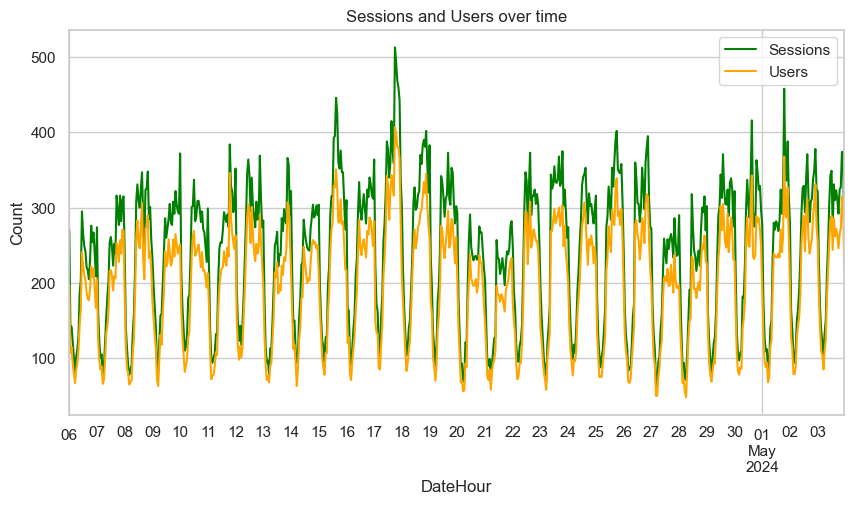

In [18]:
plt.figure(figsize=(10,5))
df.groupby("DateHour")[["Sessions","Users"]].sum().plot(ax=plt.gca(),color = ["green","orange"])
plt.title("Sessions and Users over time")
plt.xlabel("DateHour")
plt.ylabel("Count")
plt.show()

#Total users by channels 

C:\Users\tanve\AppData\Local\Temp\ipykernel_47368\3689126981.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df,x="Channel Group",y="Users",estimator=np.sum,palette="viridis")


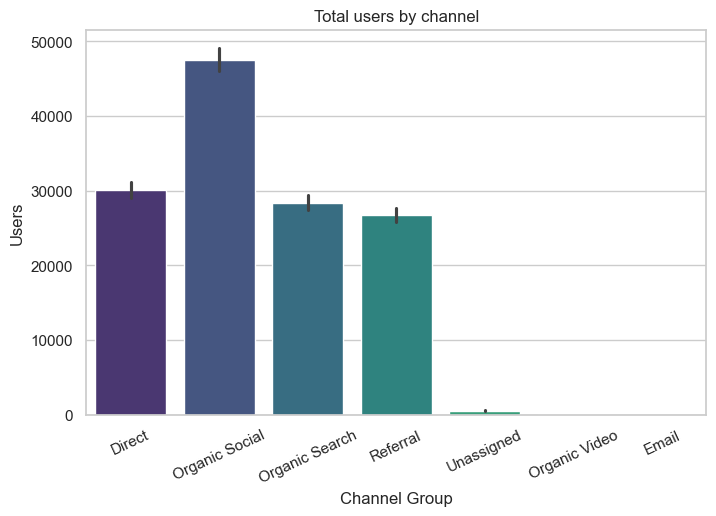

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(data = df,x="Channel Group",y="Users",estimator=np.sum,palette="viridis")
plt.title("Total users by channel")
plt.xticks(rotation=25)
plt.show()

#Average engagement time by channel

C:\Users\tanve\AppData\Local\Temp\ipykernel_47368\1253532727.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df,x="Channel Group",y="Avg Engagement Time Per session",estimator=np.mean,palette="magma")


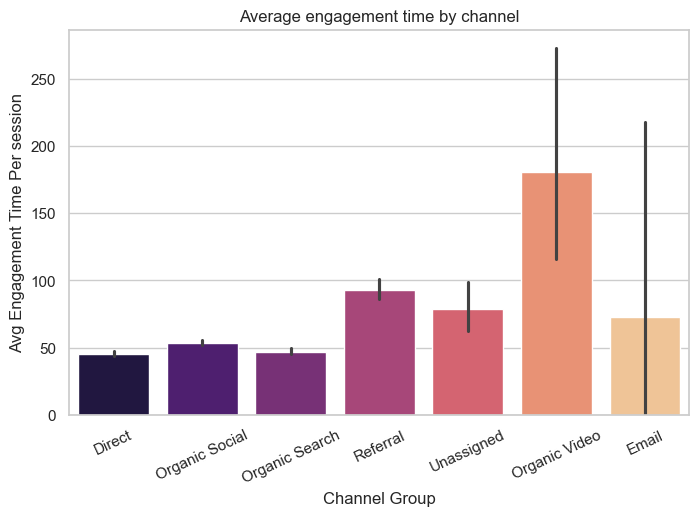

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(data = df,x="Channel Group",y="Avg Engagement Time Per session",estimator=np.mean,palette="magma")
plt.title("Average engagement time by channel")
plt.xticks(rotation=25)
plt.show()

#Engagement Rate Distribution By Channel

C:\Users\tanve\AppData\Local\Temp\ipykernel_47368\4187256551.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df,x="Channel Group",y="Engagement Rate",palette="magma")


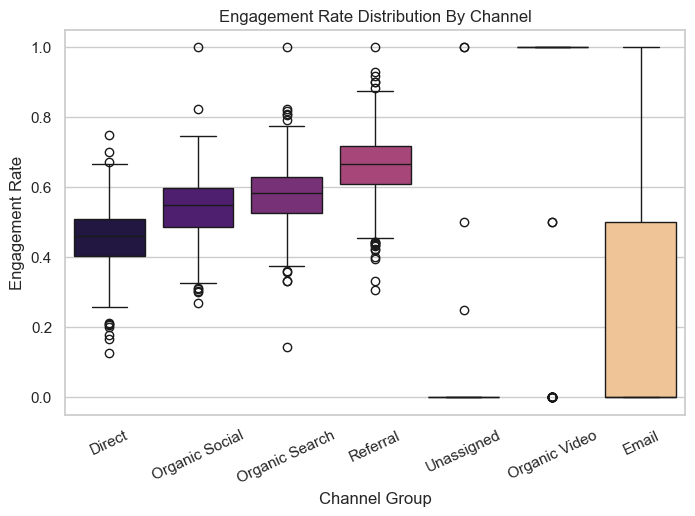

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data = df,x="Channel Group",y="Engagement Rate",palette="magma")
plt.title("Engagement Rate Distribution By Channel")
plt.xticks(rotation=25)
plt.show()

#Engaged vs Non-Engaged Sessions

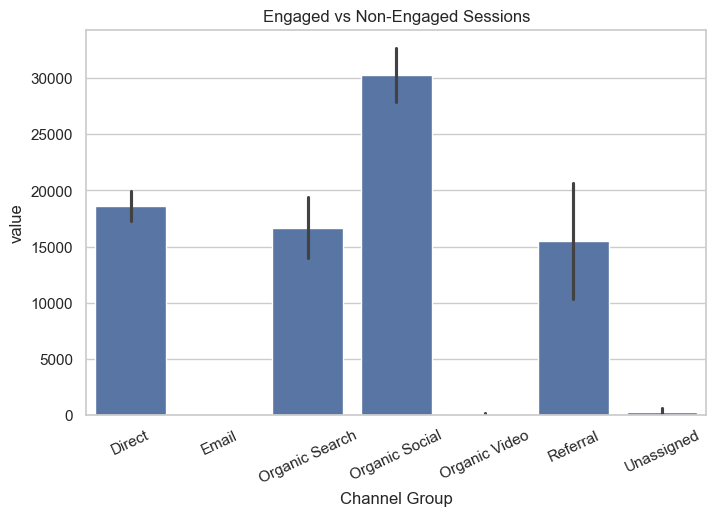

In [22]:
session_df=df.groupby("Channel Group")[["Sessions","Engaged Sessions"]].sum().reset_index()
session_df["Non Engaged"]=session_df["Sessions"]-session_df["Engaged Sessions"]
session_df_melted = session_df.melt(id_vars="Channel Group",value_vars = ["Engaged Sessions", "Non Engaged"])
plt.figure(figsize=(8,5))
sns.barplot(data = session_df_melted,x="Channel Group",y="value")
plt.title("Engaged vs Non-Engaged Sessions")
plt.xticks(rotation=25)
plt.show()

#Traffic by hour and channel

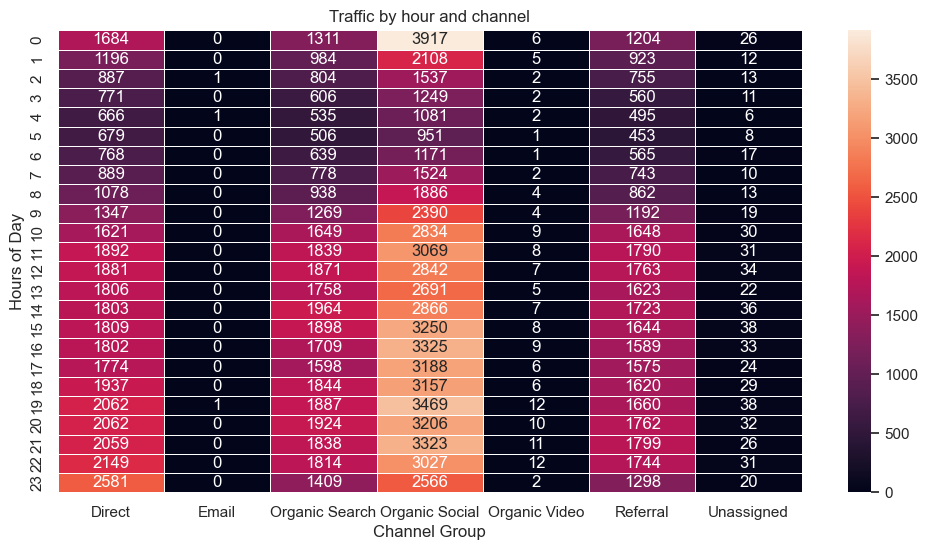

In [23]:
heatmap_data = df.groupby(["hour","Channel Group"])["Sessions"].sum().unstack().fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data  ,linewidths =.5,annot=True,fmt='.0f')
plt.title("Traffic by hour and channel")
plt.xlabel("Channel Group")
plt.ylabel("Hours of Day")
plt.show()

#Engagement rate vs sessions over time

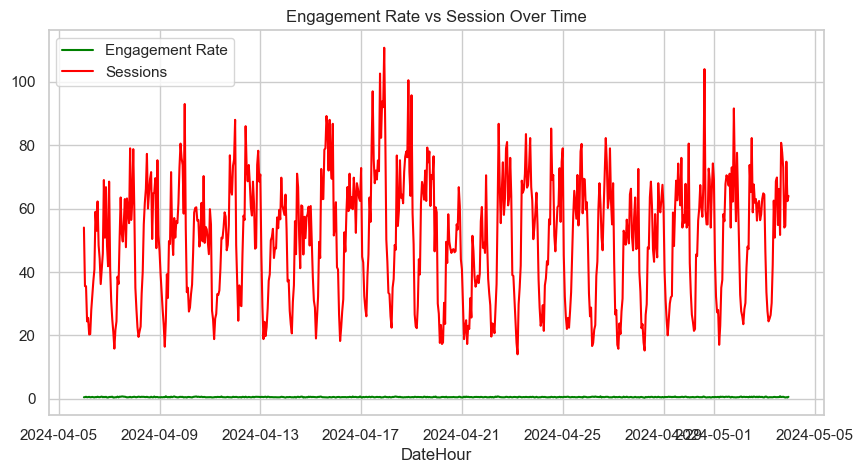

In [26]:
df_plot = df.groupby("DateHour")[["Engagement Rate","Sessions"]].mean().reset_index()
plt.figure(figsize=(10,5))
plt.plot(df_plot["DateHour"],df_plot["Engagement Rate"],label="Engagement Rate",color = "green")
plt.plot(df_plot["DateHour"],df_plot["Sessions"],label="Sessions",color = "red")
plt.title("Engagement Rate vs Session Over Time")
plt.xlabel("DateHour")
plt.legend()
plt.grid(True)
plt.show()